## 01. Exploratory Data Analysis (EDA)

This notebook performs data cleaning and exploratory data analysis on the credit card transaction dataset. It examines the dataset structure, data quality, duplicate observations, class distribution, transaction characteristics, and correlations between features and fraud. The findings from this analysis are used to guide the subsequent machine learning modelling process.


In [17]:
# Packages for EDA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
# 1. Import dataset
df = pd.read_csv("../Dataset/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

In [20]:
df.duplicated().sum()

np.int64(1081)

In [22]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates.shape)

(1854, 31)


In [12]:
print(df[df.duplicated()]["Class"].value_counts())
print(df.drop_duplicates().shape)

Class
0    1062
1      19
Name: count, dtype: int64
(283726, 31)


In [10]:
features = [col for col in df.columns if col != "Class"]

conflicting_labels = (
    df.groupby(features)["Class"]
      .nunique()
)

conflicting_labels.value_counts()

Class
1    283726
Name: count, dtype: int64

There are 283,726 unique feature combinations, and each combination has only ONE Class label.

## Duplicate Handling
The dataset initially contained 284,807 observations. A total of 1,081 exact duplicate observations were identified, consisting of 1,062 legitimate transactions and 19 fraudulent transactions. No conflicting class labels were found among identical feature combinations. Exact duplicate observations were identified in the dataset. Because the available variables are anonymized and do not provide a unique transaction identifier, it cannot be definitively established whether every exact duplicate represents the same real-world transaction or separate transactions with identical recorded characteristics. For modelling purposes, exact duplicates were removed to reduce the risk of repeated observations disproportionately influencing model training and evaluation.

In [23]:
df = df.drop_duplicates()
df.shape

(283726, 31)

# Exploratory data analysis

This section validates data quality and examines class imbalance, transaction amounts, timing, and the variables most associated with fraud. The `V1`–`V28` columns are anonymized PCA components, so their statistical relationship with `Class` is more meaningful than a business-domain interpretation.

In [24]:
# Dataset structure and data-quality checks
data_summary = pd.Series({
    'Rows': len(df),
    'Columns': df.shape[1],
    'Missing values': int(df.isna().sum().sum()),
    'Duplicated rows': int(df.duplicated().sum()),
    'Time span (hours)': round((df['Time'].max() - df['Time'].min()) / 3600, 2),
    'Negative amounts': int((df['Amount'] < 0).sum())
})
display(data_summary.to_frame('Value'))
display(df.describe().T[['mean', 'std', 'min', 'max']].round(3))

,Value
Rows,283726.0
Columns,31.0
Missing values,0.0
Duplicated rows,0.0
Time span (hours),48.0
Negative amounts,0.0


,mean,std,min,max
Time,94811.078,47481.048,0.000,172792.000
V1,0.006,1.948,-56.408,2.455
V2,-0.004,1.647,-72.716,22.058
V3,0.002,1.509,-48.326,9.383
V4,-0.003,1.414,-5.683,16.875
V5,0.002,1.377,-113.743,34.802
V6,-0.001,1.332,-26.161,73.302
V7,0.002,1.228,-43.557,120.589
V8,-0.001,1.179,-73.217,20.007
V9,-0.002,1.095,-13.434,15.595


,label,transactions,share (%)
Class,,,
0,Legitimate,283253,99.833
1,Fraud,473,0.167


,count,mean,median,std,min,max
Legitimate,283253,88.41,22.00,250.38,0.0,25691.16
Fraud,473,123.87,9.82,260.21,0.0,2125.87


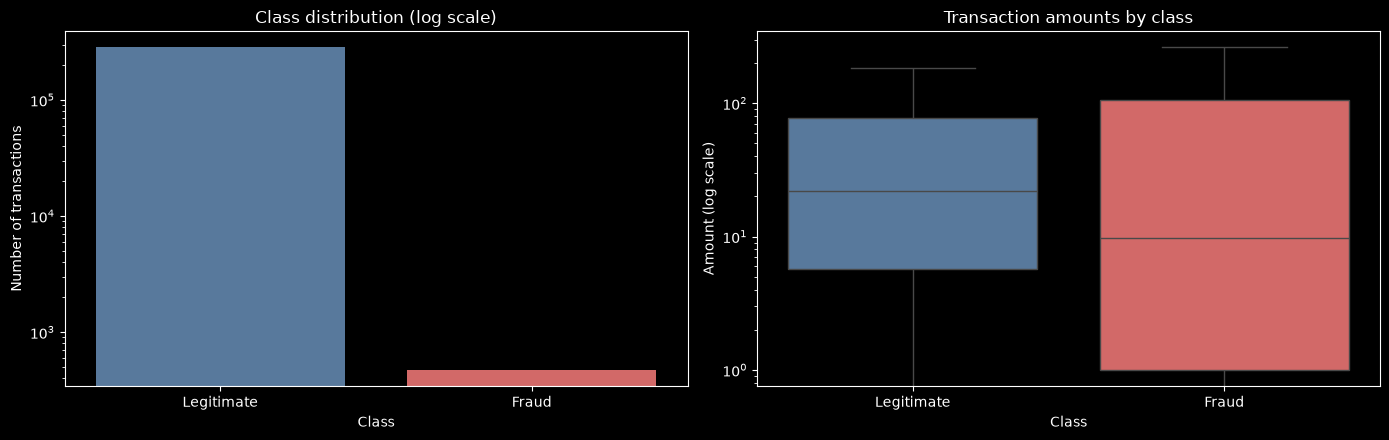

In [25]:
# Fraud prevalence and transaction-value profile
class_counts = df['Class'].value_counts().sort_index()
class_summary = pd.DataFrame({
    'label': ['Legitimate', 'Fraud'],
    'transactions': class_counts.values,
    'share (%)': (class_counts / len(df) * 100).values
}, index=class_counts.index)
display(class_summary.round(3))

amount_summary = df.groupby('Class')['Amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
amount_summary.index = ['Legitimate', 'Fraud']
display(amount_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(data=df, x='Class', hue='Class', palette=['#4C78A8', '#E45756'], legend=False, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xticks([0, 1], ['Legitimate', 'Fraud'])
axes[0].set_title('Class distribution (log scale)')
axes[0].set_ylabel('Number of transactions')

sns.boxplot(data=df, x='Class', y='Amount', hue='Class', palette=['#4C78A8', '#E45756'], legend=False, ax=axes[1], showfliers=False)
axes[1].set_xticks([0, 1], ['Legitimate', 'Fraud'])
axes[1].set_yscale('log')
axes[1].set_title('Transaction amounts by class')
axes[1].set_ylabel('Amount (log scale)')
plt.tight_layout()
plt.show()

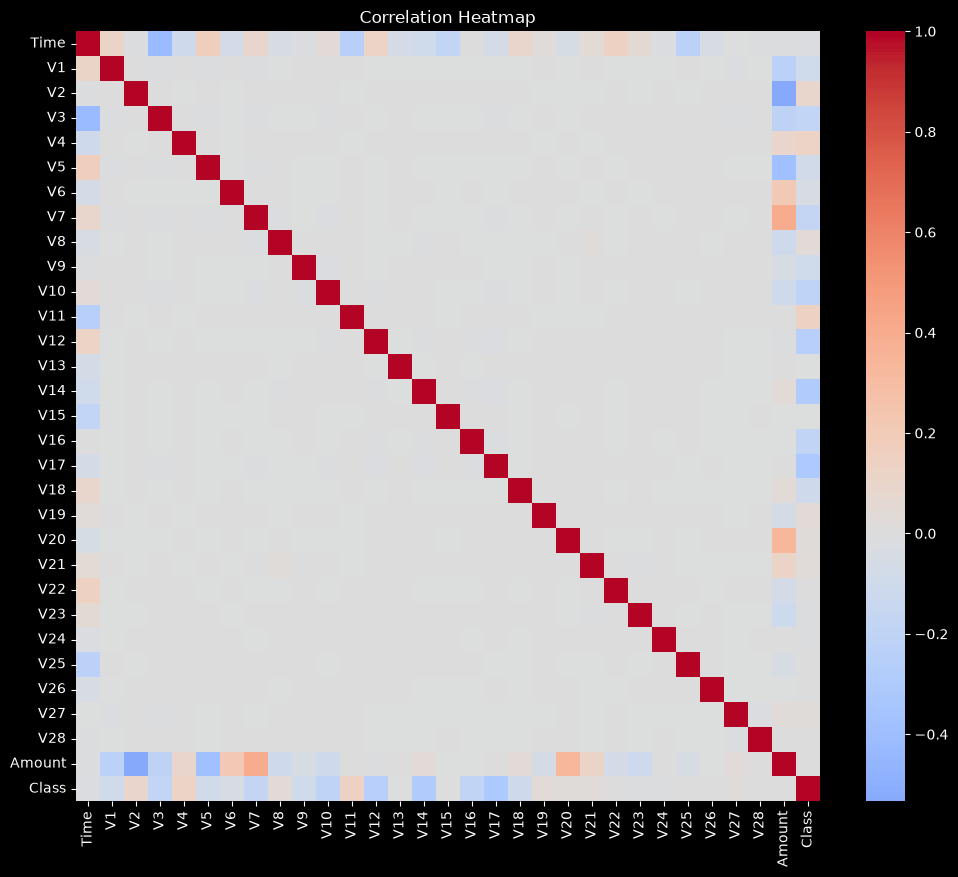

In [27]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
class_corr = corr_matrix["Class"].sort_values(ascending=False)

print(class_corr)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


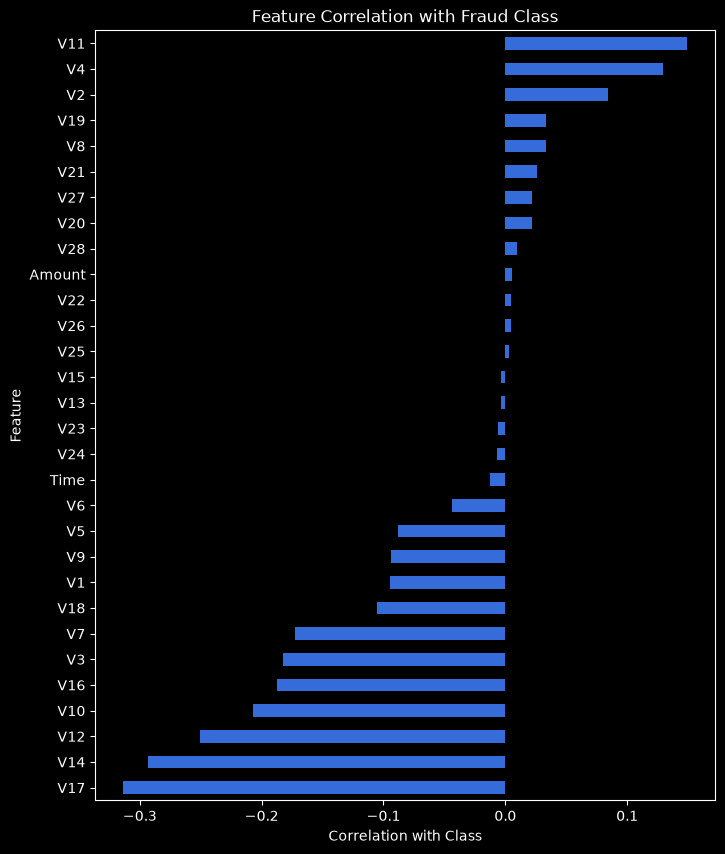

In [29]:
class_corr = corr_matrix["Class"].drop("Class").sort_values()

plt.figure(figsize=(8, 10))

class_corr.plot(kind="barh")

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

## EDA conclusions and modeling implications

- Fraud is a rare event, so accuracy alone will be misleading; prioritize precision-recall AUC, recall, precision, and a cost-aware operating threshold.
- `Amount` is strongly right-skewed; consider a `log1p` transformation for models sensitive to scale.
- Correlation analysis showed that V17, V14, V12, V10, V16, V3, and V7 had the strongest negative correlations with the fraud indicator, while V11 and V4 showed the strongest positive correlations. Transaction Amount and Time exhibited very weak linear correlations with fraud. However, correlation alone was not used for feature selection because nonlinear models such as Random Forest and XGBoost can capture nonlinear relationships and feature interactions.

In [30]:
# save cleaned dataset
df.to_csv("../Dataset/creditcard_cleaned.csv", index=False)